In [1]:
import numpy as np
from ase import Atoms
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
from mace.calculators import mace_mp
from collections import Counter

TYPE_TO_ELEMENT = {13: "Al", 27: "Co", 28: "Ni"}

def parse_fig5(path):
    lines = open(path).read().splitlines()
    text = open(path).read().split()
    cell = np.array([float(x) for x in text[:9]]).reshape(3, 3)
    symbols, scaled = [], []
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 6 and parts[3].isdigit() and parts[4].isdigit():
            typ = int(parts[3])
            if typ == 0:
                continue
            if typ in TYPE_TO_ELEMENT:
                symbols.append(TYPE_TO_ELEMENT[typ])
                scaled.append([float(parts[0]), float(parts[1]), float(parts[2])])
    return Atoms(symbols=symbols, scaled_positions=np.array(scaled), cell=cell, pbc=True)

calc = mace_mp(model="medium-mpa-0", device="cpu", default_dtype="float64")
atoms = parse_fig5("Al9Co2Ni2-coords.txt")
atoms.calc = calc
BFGS(FrechetCellFilter(atoms), logfile=None).run(fmax=0.001)
print(f"Relaxed: {len(atoms)} atoms, {dict(Counter(atoms.get_chemical_symbols()))}")
print(f"Max residual force: {np.sqrt((atoms.get_forces()**2).sum(axis=1)).max():.5f} eV/A")

/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Relaxed: 26 atoms, {'Al': 18, 'Ni': 3, 'Co': 5}
Max residual force: 0.00083 eV/A


In [2]:
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase import units
import time

md_atoms = atoms.copy()
md_atoms.calc = calc

T = 300  # K — matches Mihalkovic's 300 K MD for this exact system (Fig 2 caption)

MaxwellBoltzmannDistribution(md_atoms, temperature_K=T)
Stationary(md_atoms)   # zero net momentum -> no whole-crystal drift

timestep = 2.0 * units.fs
friction = 0.01 / units.fs
dyn = Langevin(md_atoms, timestep, temperature_K=T, friction=friction)

temps = []
def log_T():
    ekin = md_atoms.get_kinetic_energy() / len(md_atoms)
    temps.append(ekin / (1.5 * units.kB))
dyn.attach(log_T, interval=50)

print(f"Equilibrating {len(md_atoms)} atoms at {T} K for 10 ps...")
t0 = time.time()
dyn.run(5000)   # 5000 x 2fs = 10 ps
print(f"Done in {time.time()-t0:.0f}s")

temps = np.array(temps)
sh = temps[len(temps)//2:]
print(f"\nMean T (2nd half): {sh.mean():.1f} K (target {T})")
print(f"Std dev: {sh.std():.1f} K")

/opt/anaconda3/envs/mace-env/lib/python3.11/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


Equilibrating 26 atoms at 300 K for 10 ps...
Done in 1306s

Mean T (2nd half): 289.5 K (target 300)
Std dev: 49.8 K


In [3]:
from ase.md.verlet import VelocityVerlet
import numpy as np, time

# NVE production - thermostat OFF, continues from the equilibrated structure
dyn_nve = VelocityVerlet(md_atoms, timestep)   # same 2 fs timestep

# storage for velocities (and energy, to check NVE conservation)
velocities = []
energies = []
sample_every = 2          # record every 2 steps = every 4 fs
n_steps = 5000            # 5000 x 2fs = 10 ps production (short, just to prove the pipeline)

def record():
    velocities.append(md_atoms.get_velocities().copy())
    energies.append(md_atoms.get_total_energy())

dyn_nve.attach(record, interval=sample_every)

print(f"NVE production: {n_steps} steps ({n_steps*2/1000:.0f} ps), sampling every {sample_every*2} fs...")
t0 = time.time()
dyn_nve.run(n_steps)
print(f"Done in {time.time()-t0:.0f}s")

velocities = np.array(velocities)   # shape: (n_samples, n_atoms, 3)
energies = np.array(energies)
print(f"\nStored velocities: {velocities.shape}  (samples, atoms, xyz)")

# check NVE energy conservation (should be nearly flat)
drift = (energies.max() - energies.min()) / len(md_atoms) * 1000  # meV/atom
print(f"Total energy drift over run: {drift:.3f} meV/atom  (small = good NVE)")
print(f"Sampling interval: {sample_every*2} fs -> max resolvable frequency ~{1000/(2*sample_every*2)*4.1357:.0f} meV")

NVE production: 5000 steps (10 ps), sampling every 4 fs...
Done in 1353s

Stored velocities: (2501, 26, 3)  (samples, atoms, xyz)
Total energy drift over run: 0.105 meV/atom  (small = good NVE)
Sampling interval: 4 fs -> max resolvable frequency ~517 meV


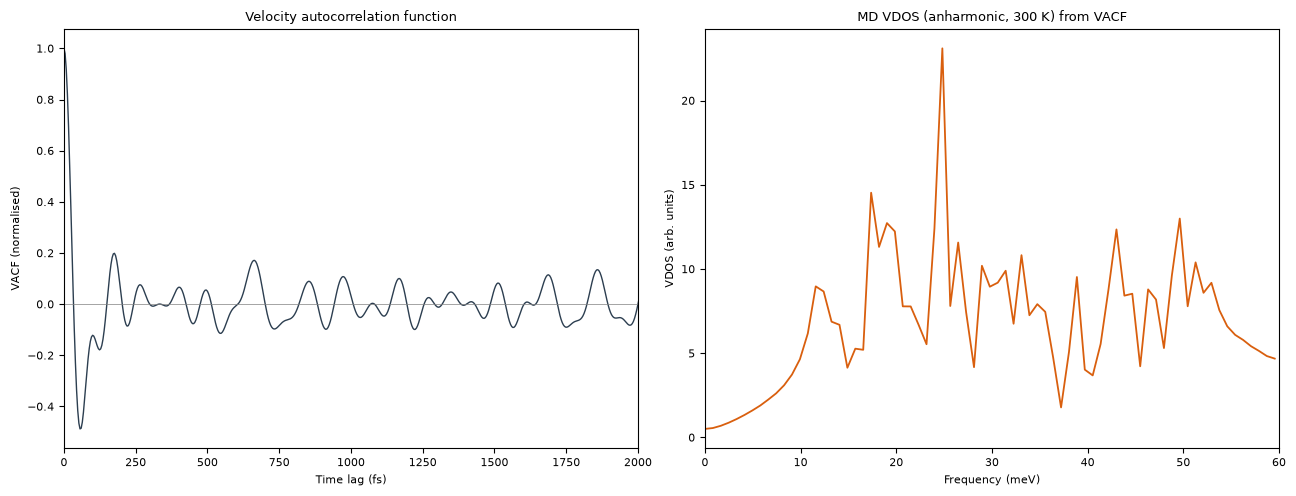

VACF computed over 1250 lags (5000 fs)
Frequency resolution: 0.83 meV


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# velocities shape: (n_samples, n_atoms, 3)
# --- compute the velocity autocorrelation function (VACF) ---
# average over atoms and time origins, for each lag
n_samples = velocities.shape[0]
max_lag = n_samples // 2      # use half the trajectory as max correlation lag

# mass-weight the VACF (heavier atoms weighted more) - standard for VDOS
from ase.data import atomic_masses, atomic_numbers
masses = np.array([atomic_masses[atomic_numbers[s]] for s in md_atoms.get_chemical_symbols()])

vacf = np.zeros(max_lag)
for lag in range(max_lag):
    # dot product of v(t+lag).v(t), summed over xyz, mass-weighted, averaged over atoms & origins
    dots = np.sum(velocities[:n_samples-lag] * velocities[lag:], axis=2)  # (origins, atoms)
    dots = dots * masses[None, :]        # mass weight
    vacf[lag] = dots.mean()
vacf /= vacf[0]      # normalise so VACF(0) = 1

# --- Fourier transform the VACF -> VDOS ---
dt = sample_every * 2 * 1e-15      # sampling interval in seconds (4 fs)
window = np.hanning(2 * len(vacf))[len(vacf):]   # half-Hann window
vacf_windowed = vacf * window

spectrum = np.abs(np.fft.rfft(vacf_windowed))
freqs_Hz = np.fft.rfftfreq(len(vacf_windowed), d=dt)   # SAME length as spectrum
freqs_meV = (freqs_Hz / 1e12) * 4.13567                # Hz -> meV
# correct conversion: 1 THz = 4.13567 meV; freqs_Hz in Hz -> THz is /1e12
freqs_meV = (freqs_Hz / 1e12) * 4.13567

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# left: the VACF itself
t_fs = np.arange(max_lag) * sample_every * 2
axes[0].plot(t_fs, vacf, color="#2c3e50", lw=1)
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].set_xlabel("Time lag (fs)"); axes[0].set_ylabel("VACF (normalised)")
axes[0].set_title("Velocity autocorrelation function")
axes[0].set_xlim(0, 2000)

# right: the VDOS
mask = (freqs_meV >= 0) & (freqs_meV <= 60)
axes[1].plot(freqs_meV[mask], spectrum[mask], color="#d95f0e", lw=1.3)
axes[1].set_xlabel("Frequency (meV)"); axes[1].set_ylabel("VDOS (arb. units)")
axes[1].set_title("MD VDOS (anharmonic, 300 K) from VACF")
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.savefig("o2_md_vdos_26atom.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"VACF computed over {max_lag} lags ({max_lag*4} fs)")
print(f"Frequency resolution: {freqs_meV[1]-freqs_meV[0]:.2f} meV")

/var/folders/3p/symqw42d0dv_htgds0njggmh0000gn/T/ipykernel_2852/2547366675.py:6: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  hd = ph.get_total_dos_dict()


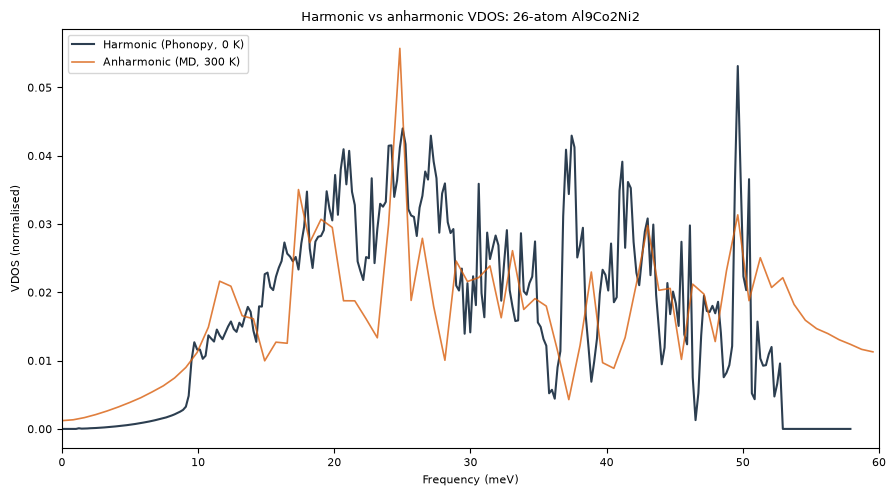

In [6]:
import phonopy

# reload harmonic VDOS for the 26-atom
ph = phonopy.load("o2_phonon_26atom.yaml")
ph.run_mesh([20,20,20]); ph.run_total_dos(freq_pitch=0.05)
hd = ph.get_total_dos_dict()
h_f = hd["frequency_points"] * 4.13567
h_dos = hd["total_dos"]

# normalise both to unit area (so shapes are comparable)
mask_md = (freqs_meV >= 0) & (freqs_meV <= 60)
md_f, md_d = freqs_meV[mask_md], spectrum[mask_md]
md_d = md_d / np.trapezoid(md_d, md_f)
h_dn = h_dos / np.trapezoid(h_dos[h_f>=0], h_f[h_f>=0])

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(h_f, h_dn, color="#2c3e50", lw=1.5, label="Harmonic (Phonopy, 0 K)")
ax.plot(md_f, md_d, color="#d95f0e", lw=1.2, alpha=0.8, label="Anharmonic (MD, 300 K)")
ax.set_xlim(0, 60); ax.set_xlabel("Frequency (meV)"); ax.set_ylabel("VDOS (normalised)")
ax.set_title("Harmonic vs anharmonic VDOS: 26-atom Al9Co2Ni2")
ax.legend()
plt.tight_layout()
plt.savefig("o2_harmonic_vs_md_26atom.png", dpi=150, bbox_inches="tight")
plt.show()